In [1]:
# ==========================
# Dependencies / Imports
# ==========================
import sys
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import xarray as xr

try:
    import netCDF4  # noqa: F401
except Exception as e:
    print("netCDF4 import failed:", e)

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("requests:", requests.__version__)
print("xarray:", xr.__version__)

Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.4.1
requests: 2.32.5
xarray: 2026.1.0


In [3]:
# ============================================================
# BUOY TEMPORAL RESOLUTION CHECK (overall + per-site)
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd

# 1) POINT THIS to your buoy CSV
BUOY_CSV = r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\data\processed\buoy_data_cleaned.csv"  # <-- EDIT

# 2) Load
df = pd.read_csv(BUOY_CSV)
print("Loaded rows:", len(df))
print("Columns:", list(df.columns))

# 3) Auto-detect likely columns (edit if needed)
def pick_col(candidates: list[str]) -> str | None:
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

time_col = pick_col(["datetime", "time", "timestamp", "date_time", "utc", "UTC"])
site_col = pick_col(["location", "site", "station", "buoy", "name"])

print("\nGuessed time_col:", time_col)
print("Guessed site_col:", site_col)

if time_col is None:
    raise ValueError("Could not auto-detect the datetime column. Set time_col manually.")

# 4) Parse datetime (handles Z / timezone safely)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True).dt.tz_convert(None)
df = df.dropna(subset=[time_col])

# 5) Basic coverage info
min_t, max_t = df[time_col].min(), df[time_col].max()
print("\nTime range:", min_t, "->", max_t)

# 6) Helper: summarize time deltas in minutes
def summarize_deltas(series_dt: pd.Series) -> dict:
    s = series_dt.sort_values()
    deltas = s.diff().dropna()
    if deltas.empty:
        return {"n": 0}

    mins = deltas.dt.total_seconds() / 60.0
    # Most-common delta (mode) via rounding to nearest minute
    rounded = mins.round().astype(int)
    mode = int(rounded.value_counts().idxmax())

    return {
        "n_deltas": int(len(mins)),
        "mode_minutes": mode,
        "p50_minutes": float(np.nanmedian(mins)),
        "p10_minutes": float(np.nanpercentile(mins, 10)),
        "p90_minutes": float(np.nanpercentile(mins, 90)),
        "min_minutes": float(np.nanmin(mins)),
        "max_minutes": float(np.nanmax(mins)),
    }

# 7) Overall delta stats
overall = summarize_deltas(df[time_col])
print("\nOverall spacing (minutes):", overall)

# 8) Counts per day / month to detect daily vs monthly behavior
df["date"] = df[time_col].dt.floor("D")
df["month"] = df[time_col].dt.to_period("M").astype(str)
daily_counts = df.groupby("date").size()
monthly_counts = df.groupby("month").size()

print("\nDays present:", daily_counts.size)
print("Median samples per day:", float(daily_counts.median()))
print("Months present:", monthly_counts.size)
print("Median samples per month:", float(monthly_counts.median()))

# 9) Per-site delta stats (if site column exists)
if site_col is not None:
    per_site = []
    for site, g in df.groupby(site_col):
        stats = summarize_deltas(g[time_col])
        per_site.append({"site": site, **stats, "rows": int(len(g))})

    per_site_df = pd.DataFrame(per_site).sort_values(["rows"], ascending=False)
    display(per_site_df.head(20))

    # Quick “what does it look like?” classification
    def classify(mode_minutes: int) -> str:
        if mode_minutes <= 5:
            return "sub-hourly"
        if 30 <= mode_minutes <= 90:
            return "hourly-ish"
        if 18*60 <= mode_minutes <= 30*60:
            return "daily-ish"
        if 20*24*60 <= mode_minutes <= 40*24*60:
            return "monthly-ish"
        return "irregular/mixed"

    per_site_df["cadence_guess"] = per_site_df["mode_minutes"].fillna(-1).astype(int).apply(
        lambda m: classify(m) if m >= 0 else "unknown"
    )
    print("\nPer-site cadence guess (top 20 by rows):")
    display(per_site_df[["site", "rows", "mode_minutes", "p50_minutes", "cadence_guess"]].head(20))
else:
    print("\nNo site column detected; skipping per-site breakdown.")

# 10) Show a few example timestamps
print("\nFirst 10 timestamps:")
display(df[[time_col] + ([site_col] if site_col else [])].sort_values(time_col).head(10))

Loaded rows: 75034
Columns: ['datetime', 'latitude', 'longitude', 'sst_celsius', 'location', 'pco2_sw_sat', 'xco2_sw_dry']

Guessed time_col: datetime
Guessed site_col: location

Time range: 2013-10-06 00:47:00 -> 2025-09-01 21:17:00

Overall spacing (minutes): {'n_deltas': 75033, 'mode_minutes': 0, 'p50_minutes': 0.0, 'p10_minutes': 0.0, 'p90_minutes': 180.0, 'min_minutes': 0.0, 'max_minutes': 311640.0}

Days present: 4077
Median samples per day: 16.0
Months present: 138
Median samples per month: 496.0


,site,n_deltas,mode_minutes,p50_minutes,p10_minutes,p90_minutes,min_minutes,max_minutes,rows
6,Southern California,22420,180,180.0,180.0,180.0,0.0,229500.0,22421
5,South Pacific,15017,180,180.0,180.0,180.0,30.0,1520460.0,15018
1,Grays Reef Georgia,9417,180,180.0,180.0,180.0,30.0,1275810.0,9418
4,SE Bering Sea,9076,180,180.0,180.0,180.0,30.0,1041300.0,9077
2,LA Buoy,8691,180,180.0,180.0,180.0,30.0,426270.0,8692
0,First Landing,5637,180,180.0,180.0,180.0,30.0,268380.0,5638
3,La Push,4769,180,180.0,180.0,180.0,30.0,1147530.0,4770



Per-site cadence guess (top 20 by rows):


,site,rows,mode_minutes,p50_minutes,cadence_guess
6,Southern California,22421,180,180.0,irregular/mixed
5,South Pacific,15018,180,180.0,irregular/mixed
1,Grays Reef Georgia,9418,180,180.0,irregular/mixed
4,SE Bering Sea,9077,180,180.0,irregular/mixed
2,LA Buoy,8692,180,180.0,irregular/mixed
0,First Landing,5638,180,180.0,irregular/mixed
3,La Push,4770,180,180.0,irregular/mixed



First 10 timestamps:


,datetime,location
63969,2013-10-06 00:47:00,South Pacific
63970,2013-10-06 01:17:00,South Pacific
63971,2013-10-06 01:47:00,South Pacific
63972,2013-10-06 02:17:00,South Pacific
63973,2013-10-06 02:47:00,South Pacific
63974,2013-10-06 03:17:00,South Pacific
63975,2013-10-06 06:17:00,South Pacific
63976,2013-10-06 09:17:00,South Pacific
63977,2013-10-06 12:17:00,South Pacific
63978,2013-10-06 15:17:00,South Pacific


In [5]:


from pathlib import Path

def find_project_root(start: Path, marker: str = "GeOceanProject") -> Path:
    p = start.resolve()
    for cand in [p] + list(p.parents):
        if cand.name == marker:
            return cand
    raise FileNotFoundError(f"Could not find project root folder named '{marker}' from {start}")

PROJECT_ROOT = find_project_root(Path.cwd(), marker="GeOceanProject")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
BUOY_CSV = PROCESSED_DIR / "buoy_data_cleaned.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BUOY_CSV exists:", BUOY_CSV.exists(), BUOY_CSV)

PROJECT_ROOT: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject
BUOY_CSV exists: True C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\data\processed\buoy_data_cleaned.csv


In [6]:
# ============================================================
# Build daily buoy dataset + reasonable ML anchor sample
# Outputs -> data/processed/
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd


# ----------------------------
# 1) Paths (already verified)
# ----------------------------
PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

BUOY_CSV = PROCESSED_DIR / "buoy_data_cleaned.csv"
assert BUOY_CSV.exists(), f"Missing buoy file: {BUOY_CSV}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BUOY_CSV:", BUOY_CSV)


# ----------------------------
# 2) Load buoy data
# ----------------------------
buoy = pd.read_csv(BUOY_CSV)
print("Loaded rows:", len(buoy))


# ----------------------------
# 3) Parse + clean
# ----------------------------
required_cols = {"datetime", "location", "latitude", "longitude", "pco2_sw_sat", "sst_celsius"}
missing = required_cols - set(buoy.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

buoy["datetime"] = pd.to_datetime(buoy["datetime"], errors="coerce", utc=True).dt.tz_convert(None)
buoy["pco2_sw_sat"] = pd.to_numeric(buoy["pco2_sw_sat"], errors="coerce")
buoy["sst_celsius"] = pd.to_numeric(buoy["sst_celsius"], errors="coerce")
buoy["latitude"] = pd.to_numeric(buoy["latitude"], errors="coerce")
buoy["longitude"] = pd.to_numeric(buoy["longitude"], errors="coerce")

buoy = buoy.dropna(subset=["datetime", "location", "latitude", "longitude", "pco2_sw_sat"])
buoy["date"] = buoy["datetime"].dt.floor("D")


# ----------------------------
# 4) Daily aggregation
# ----------------------------
daily = (
    buoy.groupby(["location", "date"], as_index=False)
        .agg(
            latitude=("latitude", "median"),
            longitude=("longitude", "median"),
            pco2_mean=("pco2_sw_sat", "mean"),
            pco2_std=("pco2_sw_sat", "std"),
            pco2_n=("pco2_sw_sat", "count"),
            sst_in_situ_mean=("sst_celsius", "mean"),
            sst_in_situ_std=("sst_celsius", "std"),
            sst_in_situ_n=("sst_celsius", "count"),
        )
        .sort_values(["location", "date"])
)

print("Daily rows:", len(daily))
display(daily.head())


# ----------------------------
# 5) QC filter: drop very sparse days
# ----------------------------
MIN_PCO2_PER_DAY = 4
daily_qc = daily[daily["pco2_n"] >= MIN_PCO2_PER_DAY].copy()

print(f"After QC (pco2_n >= {MIN_PCO2_PER_DAY}):", len(daily_qc))
print("Rows per location after QC:")
display(daily_qc["location"].value_counts())


# ----------------------------
# 6) Save daily dataset
# ----------------------------
daily_out = PROCESSED_DIR / "buoy_daily_agg.csv"
daily_qc.to_csv(daily_out, index=False)
print("Wrote:", daily_out)


# ----------------------------
# 7) Build a reasonable training anchor sample
# ----------------------------
N_SAMPLES = 2000   # start smaller; scale to 5000+ after satellite enrichment works
RANDOM_SEED = 42

if len(daily_qc) <= N_SAMPLES:
    anchors = daily_qc.copy()
else:
    # Stratified sample by location to avoid one site dominating
    sizes = daily_qc["location"].value_counts()
    props = sizes / sizes.sum()

    alloc = (props * N_SAMPLES).round().astype(int)

    # ensure at least 50 per site if possible
    min_per_site = 50
    alloc[alloc < min_per_site] = min_per_site

    # adjust to sum exactly N_SAMPLES
    diff = int(alloc.sum() - N_SAMPLES)
    if diff != 0:
        order = alloc.sort_values(ascending=False).index.tolist()
        i = 0
        while diff != 0 and i < len(order) * 10:
            k = order[i % len(order)]
            if diff > 0 and alloc[k] > min_per_site:
                alloc[k] -= 1
                diff -= 1
            elif diff < 0:
                alloc[k] += 1
                diff += 1
            i += 1

    rng = np.random.default_rng(RANDOM_SEED)
    parts = []
    for loc, n in alloc.items():
        g = daily_qc[daily_qc["location"] == loc]
        if len(g) == 0:
            continue
        take = min(int(n), len(g))
        idx = rng.choice(g.index.to_numpy(), size=take, replace=False)
        parts.append(daily_qc.loc[idx])

    anchors = (
        pd.concat(parts, ignore_index=True)
          .sample(frac=1, random_state=RANDOM_SEED)
          .reset_index(drop=True)
    )

print("Anchor rows:", len(anchors))
print("Anchors per location:")
display(anchors["location"].value_counts())
display(anchors.head())


# ----------------------------
# 8) Save anchors
# ----------------------------
anchors_out = PROCESSED_DIR / f"train_anchors_sample_{len(anchors)}.csv"
anchors.to_csv(anchors_out, index=False)
print("Wrote:", anchors_out)

PROJECT_ROOT: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject
BUOY_CSV: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\data\processed\buoy_data_cleaned.csv
Loaded rows: 75034
Daily rows: 8814


,location,date,latitude,longitude,pco2_mean,pco2_std,pco2_n,sst_in_situ_mean,sst_in_situ_std,sst_in_situ_n
0,First Landing,2018-04-05,36.998,-76.088,234.016667,6.130063,6,9.381500,0.362841,6
1,First Landing,2018-04-06,36.998,-76.088,269.233333,31.105385,9,9.272556,0.470113,9
2,First Landing,2018-04-07,36.998,-76.088,237.012500,16.799102,8,9.779375,0.302039,8
3,First Landing,2018-04-08,36.998,-76.088,269.262500,22.764693,8,8.977250,0.400137,8
4,First Landing,2018-04-09,36.998,-76.088,298.562500,19.055328,8,8.877375,0.521280,8


After QC (pco2_n >= 4): 8487
Rows per location after QC:


location
Southern California    2784
South Pacific          1368
Grays Reef Georgia     1161
LA Buoy                1046
SE Bering Sea          1020
First Landing           695
La Push                 413
Name: count, dtype: int64

Wrote: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\data\processed\buoy_daily_agg.csv
Anchor rows: 2000
Anchors per location:


location
Southern California    657
South Pacific          322
Grays Reef Georgia     274
LA Buoy                246
SE Bering Sea          240
First Landing          164
La Push                 97
Name: count, dtype: int64

,location,date,latitude,longitude,pco2_mean,pco2_std,pco2_n,sst_in_situ_mean,sst_in_situ_std,sst_in_situ_n
0,First Landing,2018-12-22,36.998,-76.088,234.5125,70.801744,8,8.298625,0.343696,8
1,Southern California,2023-09-07,34.303,-120.801,378.8225,1.683871,8,17.618500,0.301200,8
2,LA Buoy,2021-01-25,28.867,-90.485,273.8250,6.417331,8,18.152875,0.101551,8
3,South Pacific,2015-08-18,0.000,-154.919,457.1500,2.356147,8,29.337625,0.103630,8
4,LA Buoy,2021-08-13,28.867,-90.485,350.1750,23.579140,4,30.532500,0.241551,4


Wrote: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\data\processed\train_anchors_sample_2000.csv


In [3]:
# ============================================================
# Small-sample satellite SST fetch — 10 rows per site
# KEEPS INDIVIDUAL PIXELS (not averaged) for ML training
# Uses buoy_daily_agg.csv dates/locations directly
# Output -> data/processed/sat_sst_pixels_test_70rows.csv
# ============================================================

from __future__ import annotations

import math
import time
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ----------------------------
# Paths — everything saves to data/processed/
# ----------------------------
PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DAILY_CSV = PROCESSED_DIR / "buoy_daily_agg.csv"

assert DAILY_CSV.exists(), f"Missing: {DAILY_CSV}"

# ----------------------------
# 1) Load daily buoy data and sample 10 rows per site
# ----------------------------
daily = pd.read_csv(DAILY_CSV)
daily["date"] = pd.to_datetime(daily["date"])

ROWS_PER_SITE = 10
RANDOM_SEED = 42
BOX_KM = 12.0  # 12 km box → ~144 pixels per day at 1 km MUR resolution

sample = (
    daily.groupby("location", group_keys=False)
         .apply(lambda g: g.sample(n=min(ROWS_PER_SITE, len(g)), random_state=RANDOM_SEED))
         .reset_index(drop=True)
)

print(f"Sampled {len(sample)} buoy-days across {sample['location'].nunique()} sites")
print(sample["location"].value_counts())
print()
print("Date range per site:")
for loc, g in sample.groupby("location"):
    print(f"  {loc}: {g['date'].min().date()} -> {g['date'].max().date()} ({len(g)} rows)")

# ----------------------------
# 2) ERDDAP MUR SST config
# ----------------------------
ERDDAP_SERVER = "https://coastwatch.pfeg.noaa.gov/erddap"
DATASET_ID = "jplMURSST41"
VAR = "analysed_sst"


def bbox_km(lat: float, lon: float, box_km: float):
    """Return (lat_min, lat_max, lon_min, lon_max) for a square box centered on lat/lon."""
    half = box_km / 2.0
    dlat = half / 111.32
    dlon = half / (111.32 * math.cos(math.radians(lat)))
    return (lat - dlat, lat + dlat, lon - dlon, lon + dlon)


def haversine_km(lat1, lon1, lat2, lon2):
    """Distance in km between two points."""
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def fetch_mur_sst_pixels(lat: float, lon: float, date: pd.Timestamp, timeout: int = 60) -> pd.DataFrame | None:
    """
    Query ERDDAP for MUR SST on a single day within a 12km box.
    Returns a DataFrame with one row per pixel: [pixel_lat, pixel_lon, sat_sst_c]
    """
    date_str = date.strftime("%Y-%m-%dT09:00:00Z")
    lat_min, lat_max, lon_min, lon_max = bbox_km(lat, lon, BOX_KM)

    url = (
        f"{ERDDAP_SERVER}/griddap/{DATASET_ID}.csv?"
        f"{VAR}[({date_str}):1:({date_str})]"
        f"[({lat_min}):1:({lat_max})]"
        f"[({lon_min}):1:({lon_max})]"
    )

    for attempt in range(3):
        try:
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()

            lines = resp.text.strip().split("\n")
            if len(lines) < 3:
                return None

            # Skip units row (row 2)
            data_text = lines[0] + "\n" + "\n".join(lines[2:])
            df_resp = pd.read_csv(StringIO(data_text))

            if VAR not in df_resp.columns:
                print(f"  WARNING: unexpected columns: {list(df_resp.columns)}")
                return None

            # Rename to clean column names
            df_resp = df_resp.rename(columns={
                "latitude": "pixel_lat",
                "longitude": "pixel_lon",
                VAR: "sat_sst_c",
            })

            df_resp["sat_sst_c"] = pd.to_numeric(df_resp["sat_sst_c"], errors="coerce")
            df_resp = df_resp.dropna(subset=["sat_sst_c"])

            if df_resp.empty:
                return None

            # Convert Kelvin -> Celsius if needed
            if df_resp["sat_sst_c"].mean() > 100:
                df_resp["sat_sst_c"] -= 273.15

            return df_resp[["pixel_lat", "pixel_lon", "sat_sst_c"]]

        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  FAILED after 3 attempts: {e}")
                return None


# ----------------------------
# 3) Fetch SST pixels for each sampled buoy-day
# ----------------------------
print("\nFetching MUR SST pixels for each sample row...")
all_pixels = []

for i, row in sample.iterrows():
    loc = row["location"]
    buoy_lat = row["latitude"]
    buoy_lon = row["longitude"]
    date = row["date"]

    pixels = fetch_mur_sst_pixels(buoy_lat, buoy_lon, date)

    if pixels is not None and len(pixels) > 0:
        # Add buoy context to each pixel row
        pixels = pixels.copy()
        pixels["location"] = loc
        pixels["date"] = date
        pixels["buoy_lat"] = buoy_lat
        pixels["buoy_lon"] = buoy_lon
        pixels["pco2_mean"] = row["pco2_mean"]
        pixels["sst_in_situ_mean"] = row["sst_in_situ_mean"]
        # Distance from this pixel to the buoy
        pixels["dist_to_buoy_km"] = pixels.apply(
            lambda p: round(haversine_km(buoy_lat, buoy_lon, p["pixel_lat"], p["pixel_lon"]), 2), axis=1
        )
        all_pixels.append(pixels)
        print(f"  [{i+1}/{len(sample)}] {loc} {date.date()} -> {len(pixels)} pixels")
    else:
        print(f"  [{i+1}/{len(sample)}] {loc} {date.date()} -> MISSING")

# ----------------------------
# 4) Combine and save
# ----------------------------
if all_pixels:
    result_df = pd.concat(all_pixels, ignore_index=True)

    # Reorder columns for clarity
    result_df = result_df[[
        "location", "date",
        "buoy_lat", "buoy_lon",
        "pixel_lat", "pixel_lon", "dist_to_buoy_km",
        "sat_sst_c",
        "sst_in_situ_mean", "pco2_mean",
    ]]

    n_buoy_days = result_df.groupby(["location", "date"]).ngroups
    print(f"\n--- SUMMARY ---")
    print(f"Buoy-days with satellite data: {n_buoy_days} / {len(sample)}")
    print(f"Total pixel rows: {len(result_df)}")
    print(f"Avg pixels per buoy-day: {len(result_df) / n_buoy_days:.0f}")
    print(f"\nPer site:")
    print(result_df.groupby("location").agg(
        buoy_days=("date", "nunique"),
        total_pixels=("sat_sst_c", "count"),
        sst_mean=("sat_sst_c", "mean"),
    ).to_string())

    # Save with descriptive filename
    out_path = PROCESSED_DIR / "sat_sst_pixels_test_70rows.csv"
    result_df.to_csv(out_path, index=False)
    print(f"\nSaved -> {out_path.name}")
    print(f"  ({len(result_df)} rows in {PROCESSED_DIR})")

    display(result_df.head(10))
else:
    print("\nNo satellite data retrieved. Check ERDDAP connectivity.")


C:\Users\Owner\AppData\Local\Temp\ipykernel_21472\2595725264.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(ROWS_PER_SITE, len(g)), random_state=RANDOM_SEED))


Sampled 70 buoy-days across 7 sites
location
First Landing          10
Grays Reef Georgia     10
LA Buoy                10
La Push                10
SE Bering Sea          10
South Pacific          10
Southern California    10
Name: count, dtype: int64

Date range per site:
  First Landing: 2018-09-28 -> 2020-08-30 (10 rows)
  Grays Reef Georgia: 2016-08-28 -> 2023-03-11 (10 rows)
  LA Buoy: 2020-01-21 -> 2023-05-01 (10 rows)
  La Push: 2021-06-28 -> 2022-10-29 (10 rows)
  SE Bering Sea: 2017-05-29 -> 2023-08-30 (10 rows)
  South Pacific: 2013-11-18 -> 2023-11-30 (10 rows)
  Southern California: 2016-07-15 -> 2023-08-02 (10 rows)

Fetching MUR SST pixels for each sample row...
  [1/70] First Landing 2019-05-16 -> 180 pixels
  [2/70] First Landing 2020-08-30 -> 180 pixels
  [3/70] First Landing 2018-12-18 -> 180 pixels
  [4/70] First Landing 2019-04-03 -> 180 pixels
  [5/70] First Landing 2019-02-18 -> 180 pixels
  [6/70] First Landing 2018-11-02 -> 180 pixels
  [7/70] First Landing 201

,location,date,buoy_lat,buoy_lon,pixel_lat,pixel_lon,dist_to_buoy_km,sat_sst_c,sst_in_situ_mean,pco2_mean
0,First Landing,2019-05-16,36.998,-76.088,36.94,-76.16,9.08,19.450,18.66475,290.0625
1,First Landing,2019-05-16,36.998,-76.088,36.94,-76.15,8.48,19.415,18.66475,290.0625
2,First Landing,2019-05-16,36.998,-76.088,36.94,-76.14,7.93,19.382,18.66475,290.0625
3,First Landing,2019-05-16,36.998,-76.088,36.94,-76.13,7.45,19.350,18.66475,290.0625
4,First Landing,2019-05-16,36.998,-76.088,36.94,-76.12,7.05,19.317,18.66475,290.0625
5,First Landing,2019-05-16,36.998,-76.088,36.94,-76.11,6.74,19.283,18.66475,290.0625
6,First Landing,2019-05-16,36.998,-76.088,36.94,-76.10,6.54,19.249,18.66475,290.0625
7,First Landing,2019-05-16,36.998,-76.088,36.94,-76.09,6.45,19.213,18.66475,290.0625
8,First Landing,2019-05-16,36.998,-76.088,36.94,-76.08,6.49,19.175,18.66475,290.0625
9,First Landing,2019-05-16,36.998,-76.088,36.94,-76.07,6.64,19.136,18.66475,290.0625


In [5]:
# ============================================================
# Fetch satellite Chlorophyll-a for the SAME 70 buoy-days
# Uses MODIS Aqua 8-day composite (erdMH1chla8day) via ERDDAP
# Keeps individual pixels, same approach as SST cell above
# Output -> data/processed/sat_chla_pixels_test_70rows.csv
# ============================================================

from __future__ import annotations

import math
import time
from io import StringIO
from datetime import timedelta

import numpy as np
import pandas as pd
import requests

# ----------------------------
# Reuse paths + sample from SST cell (already in memory)
# ----------------------------
# sample, PROCESSED_DIR, BOX_KM are still loaded from cell 6

print(f"Using same {len(sample)} buoy-days from SST test")
print(f"Box size: {BOX_KM} km")

# ----------------------------
# ERDDAP Chl-a config
# ----------------------------
CHLA_SERVER = "https://coastwatch.pfeg.noaa.gov/erddap"
CHLA_DATASET = "erdMH1chla8day"   # MODIS Aqua, 8-day composite, ~4 km resolution
CHLA_VAR = "chlorophyll"


def bbox_km_chla(lat: float, lon: float, box_km: float):
    """Return (lat_min, lat_max, lon_min, lon_max) for a square box centered on lat/lon."""
    half = box_km / 2.0
    dlat = half / 111.32
    dlon = half / (111.32 * math.cos(math.radians(lat)))
    return (lat - dlat, lat + dlat, lon - dlon, lon + dlon)


def haversine_km_chla(lat1, lon1, lat2, lon2):
    """Distance in km between two points."""
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def fetch_chla_pixels(lat: float, lon: float, date: pd.Timestamp, timeout: int = 60) -> pd.DataFrame | None:
    """
    Query ERDDAP for MODIS Aqua 8-day chl-a composites near a target date.
    
    Strategy: request a 16-day window centered on the target date.
    The 8-day composite dataset will return whichever composites overlap that window
    (usually 1-2 composites). We then keep the composite closest to the target date.
    """
    # 16-day window to catch the nearest 8-day composite
    start_date = (date - timedelta(days=8)).strftime("%Y-%m-%dT00:00:00Z")
    end_date = (date + timedelta(days=8)).strftime("%Y-%m-%dT00:00:00Z")
    
    lat_min, lat_max, lon_min, lon_max = bbox_km_chla(lat, lon, BOX_KM)

    url = (
        f"{CHLA_SERVER}/griddap/{CHLA_DATASET}.csv?"
        f"{CHLA_VAR}[({start_date}):1:({end_date})]"
        f"[({lat_min}):1:({lat_max})]"
        f"[({lon_min}):1:({lon_max})]"
    )

    for attempt in range(3):
        try:
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()

            lines = resp.text.strip().split("\n")
            if len(lines) < 3:
                return None

            # Skip units row (row 2)
            data_text = lines[0] + "\n" + "\n".join(lines[2:])
            df_resp = pd.read_csv(StringIO(data_text))

            if CHLA_VAR not in df_resp.columns:
                print(f"  WARNING: unexpected columns: {list(df_resp.columns)}")
                return None

            df_resp[CHLA_VAR] = pd.to_numeric(df_resp[CHLA_VAR], errors="coerce")
            df_resp = df_resp.dropna(subset=[CHLA_VAR])

            if df_resp.empty:
                return None

            # Pick the composite date closest to the target date
            df_resp["time"] = pd.to_datetime(df_resp["time"], utc=True).dt.tz_localize(None)
            df_resp["days_from_target"] = (df_resp["time"] - date).abs().dt.days
            best_time = df_resp.loc[df_resp["days_from_target"].idxmin(), "time"]
            df_resp = df_resp[df_resp["time"] == best_time].copy()

            # Rename columns
            df_resp = df_resp.rename(columns={
                "latitude": "pixel_lat",
                "longitude": "pixel_lon",
                CHLA_VAR: "sat_chla_mg_m3",
            })

            # Record which composite date was used and how many days offset
            df_resp["chla_composite_date"] = best_time
            df_resp["chla_days_offset"] = int((best_time - date).days)

            return df_resp[["pixel_lat", "pixel_lon", "sat_chla_mg_m3", "chla_composite_date", "chla_days_offset"]]

        except requests.exceptions.HTTPError:
            if resp.status_code == 404:
                return None
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  FAILED after 3 attempts (HTTP {resp.status_code})")
                return None
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  FAILED after 3 attempts: {e}")
                return None


# ----------------------------
# Fetch chl-a pixels for each sampled buoy-day
# ----------------------------
print("\nFetching MODIS Aqua chl-a for each sample row...")
chla_pixels = []

for i, row in sample.iterrows():
    loc = row["location"]
    buoy_lat = row["latitude"]
    buoy_lon = row["longitude"]
    date = row["date"]

    pixels = fetch_chla_pixels(buoy_lat, buoy_lon, date)

    if pixels is not None and len(pixels) > 0:
        pixels = pixels.copy()
        pixels["location"] = loc
        pixels["date"] = date
        pixels["buoy_lat"] = buoy_lat
        pixels["buoy_lon"] = buoy_lon
        pixels["pco2_mean"] = row["pco2_mean"]
        pixels["sst_in_situ_mean"] = row["sst_in_situ_mean"]
        pixels["dist_to_buoy_km"] = pixels.apply(
            lambda p: round(haversine_km_chla(buoy_lat, buoy_lon, p["pixel_lat"], p["pixel_lon"]), 2), axis=1
        )
        chla_pixels.append(pixels)
        offset = pixels["chla_days_offset"].iloc[0]
        print(f"  [{i+1}/{len(sample)}] {loc} {date.date()} -> {len(pixels)} pixels (composite offset: {offset:+d} days)")
    else:
        print(f"  [{i+1}/{len(sample)}] {loc} {date.date()} -> MISSING (cloud cover likely)")

# ----------------------------
# Combine and save
# ----------------------------
if chla_pixels:
    chla_df = pd.concat(chla_pixels, ignore_index=True)

    # Reorder columns
    chla_df = chla_df[[
        "location", "date",
        "buoy_lat", "buoy_lon",
        "pixel_lat", "pixel_lon", "dist_to_buoy_km",
        "sat_chla_mg_m3", "chla_composite_date", "chla_days_offset",
        "sst_in_situ_mean", "pco2_mean",
    ]]

    n_buoy_days = chla_df.groupby(["location", "date"]).ngroups
    n_total = len(sample)
    pct = n_buoy_days / n_total * 100
    print(f"\n--- SUMMARY ---")
    print(f"Buoy-days with chl-a data: {n_buoy_days} / {n_total} ({pct:.0f}%)")
    print(f"Total pixel rows: {len(chla_df)}")
    print(f"Avg pixels per buoy-day: {len(chla_df) / n_buoy_days:.0f}")
    print(f"\nPer site:")
    print(chla_df.groupby("location").agg(
        buoy_days=("date", "nunique"),
        total_pixels=("sat_chla_mg_m3", "count"),
        chla_mean=("sat_chla_mg_m3", "mean"),
        chla_median=("sat_chla_mg_m3", "median"),
    ).to_string())

    # Save
    out_path = PROCESSED_DIR / "sat_chla_pixels_test_70rows.csv"
    chla_df.to_csv(out_path, index=False)
    print(f"\nSaved -> {out_path.name}")
    print(f"  ({len(chla_df)} rows in {PROCESSED_DIR})")

    display(chla_df.head(10))
else:
    print("\nNo chl-a data retrieved. This could be due to cloud cover or ERDDAP issues.")

Using same 70 buoy-days from SST test
Box size: 12.0 km

Fetching MODIS Aqua chl-a for each sample row...
  [1/70] First Landing 2019-05-16 -> 12 pixels (composite offset: -3 days)
  [2/70] First Landing 2020-08-30 -> 15 pixels (composite offset: +2 days)
  [3/70] First Landing 2018-12-18 -> 14 pixels (composite offset: +18 days)
  [4/70] First Landing 2019-04-03 -> 16 pixels (composite offset: +0 days)
  [5/70] First Landing 2019-02-18 -> 16 pixels (composite offset: -4 days)
  [6/70] First Landing 2018-11-02 -> 16 pixels (composite offset: +3 days)
  [7/70] First Landing 2019-05-02 -> 8 pixels (composite offset: +3 days)
  [8/70] First Landing 2018-09-28 -> 14 pixels (composite offset: -2 days)
  [9/70] First Landing 2019-03-31 -> 16 pixels (composite offset: +3 days)
  [10/70] First Landing 2018-12-17 -> 16 pixels (composite offset: -18 days)
  [11/70] Grays Reef Georgia 2019-03-28 -> 12 pixels (composite offset: -2 days)
  [12/70] Grays Reef Georgia 2019-08-10 -> 12 pixels (composi

,location,date,buoy_lat,buoy_lon,pixel_lat,pixel_lon,dist_to_buoy_km,sat_chla_mg_m3,chla_composite_date,chla_days_offset,sst_in_situ_mean,pco2_mean
0,First Landing,2019-05-16,36.998,-76.088,37.062500,-76.145830,8.82,8.065208,2019-05-13,-3,18.66475,290.0625
1,First Landing,2019-05-16,36.998,-76.088,37.062500,-76.104164,7.31,7.411808,2019-05-13,-3,18.66475,290.0625
2,First Landing,2019-05-16,36.998,-76.088,37.062500,-76.062500,7.52,7.915845,2019-05-13,-3,18.66475,290.0625
3,First Landing,2019-05-16,36.998,-76.088,37.062500,-76.020830,9.33,9.819084,2019-05-13,-3,18.66475,290.0625
4,First Landing,2019-05-16,36.998,-76.088,37.020832,-76.145830,5.73,10.380989,2019-05-13,-3,18.66475,290.0625
5,First Landing,2019-05-16,36.998,-76.088,37.020832,-76.104164,2.92,8.904404,2019-05-13,-3,18.66475,290.0625
6,First Landing,2019-05-16,36.998,-76.088,37.020832,-76.062500,3.40,8.420127,2019-05-13,-3,18.66475,290.0625
7,First Landing,2019-05-16,36.998,-76.088,37.020832,-76.020830,6.48,7.463563,2019-05-13,-3,18.66475,290.0625
8,First Landing,2019-05-16,36.998,-76.088,36.979164,-76.145830,5.55,11.212398,2019-05-13,-3,18.66475,290.0625
9,First Landing,2019-05-16,36.998,-76.088,36.979164,-76.104164,2.54,10.428580,2019-05-13,-3,18.66475,290.0625


## Building the ML Training Dataset

In the cells above we:
1. **Explored the buoy data** — checked temporal resolution, parsed timestamps, identified 7 NOAA OCADS sites with sub-hourly measurements (2013–2025)
2. **Aggregated to daily values** — computed daily mean pCO2 and in-situ SST per site, filtered to days with >=4 pCO2 observations (8,487 quality-controlled buoy-days)
3. **Tested satellite SST fetch** (10 rows/site, 70 total) — queried MUR SST (~1 km, daily) via ERDDAP, keeping individual pixels in a 12 km box around each buoy. Result: 98.6% coverage, ~177 pixels per buoy-day
4. **Tested satellite Chl-a fetch** (same 70 buoy-days) — queried MODIS Aqua 8-day composites (~4 km) via ERDDAP, picking the nearest composite to each buoy date. Result: 67% coverage (~14 pixels/day, cloud gaps expected)

**Key insight**: For ML training we need **one row per buoy-day** (not per pixel), so we summarize each satellite pixel grid into statistics (mean, std, min, max, median, closest-pixel value). This gives us ~700 independent training samples with ~15 features to predict pCO2.

The cell below scales up to **100 buoy-days per site** and fetches both SST + Chl-a in a single pass, producing a clean training CSV.


In [2]:
# ============================================================
# Combined SST + Chl-a fetch → one-row-per-buoy-day training set
# Samples 100 buoy-days per site (~700 total)
# Fetches pixel grids, summarizes to per-day stats, merges
# Output -> data/processed/training_data_700.csv
# ============================================================

from __future__ import annotations

import math
import time
from io import StringIO
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import requests

# ----------------------------
# CONFIG — change these knobs
# ----------------------------
ROWS_PER_SITE = 100
RANDOM_SEED = 42
BOX_KM = 12.0

PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DAILY_CSV = PROCESSED_DIR / "buoy_daily_agg.csv"
assert DAILY_CSV.exists(), f"Missing: {DAILY_CSV}"

# ERDDAP endpoints
ERDDAP = "https://coastwatch.pfeg.noaa.gov/erddap"
SST_DATASET = "jplMURSST41"
SST_VAR = "analysed_sst"
CHLA_DATASET = "erdMH1chla8day"
CHLA_VAR = "chlorophyll"

# ----------------------------
# 1) Sample 100 buoy-days per site
# ----------------------------
daily = pd.read_csv(DAILY_CSV)
daily["date"] = pd.to_datetime(daily["date"])

sample = (
    daily.groupby("location", group_keys=False)
         .apply(lambda g: g.sample(n=min(ROWS_PER_SITE, len(g)), random_state=RANDOM_SEED))
         .reset_index(drop=True)
)

print(f"Sampled {len(sample)} buoy-days across {sample['location'].nunique()} sites")
print(sample["location"].value_counts().to_string())
print()

# ----------------------------
# 2) Helper functions
# ----------------------------
def bbox_km(lat: float, lon: float, box_km: float):
    half = box_km / 2.0
    dlat = half / 111.32
    dlon = half / (111.32 * math.cos(math.radians(lat)))
    return (lat - dlat, lat + dlat, lon - dlon, lon + dlon)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def _parse_erddap_csv(text: str) -> pd.DataFrame | None:
    """Parse ERDDAP CSV response, skipping the units row."""
    lines = text.strip().split("\n")
    if len(lines) < 3:
        return None
    data_text = lines[0] + "\n" + "\n".join(lines[2:])
    return pd.read_csv(StringIO(data_text))


def fetch_sst_pixels(lat, lon, date, timeout=60):
    """Fetch MUR SST grid for one buoy-day. Returns DataFrame or None."""
    date_str = date.strftime("%Y-%m-%dT09:00:00Z")
    lat_min, lat_max, lon_min, lon_max = bbox_km(lat, lon, BOX_KM)
    url = (
        f"{ERDDAP}/griddap/{SST_DATASET}.csv?"
        f"{SST_VAR}[({date_str}):1:({date_str})]"
        f"[({lat_min}):1:({lat_max})]"
        f"[({lon_min}):1:({lon_max})]"
    )
    for attempt in range(3):
        try:
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()
            df = _parse_erddap_csv(resp.text)
            if df is None or SST_VAR not in df.columns:
                return None
            df[SST_VAR] = pd.to_numeric(df[SST_VAR], errors="coerce")
            df = df.dropna(subset=[SST_VAR])
            if df.empty:
                return None
            if df[SST_VAR].mean() > 100:
                df[SST_VAR] -= 273.15
            df = df.rename(columns={"latitude": "pixel_lat", "longitude": "pixel_lon", SST_VAR: "sst_c"})
            return df[["pixel_lat", "pixel_lon", "sst_c"]]
        except Exception:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                return None


def fetch_chla_pixels(lat, lon, date, timeout=60):
    """Fetch MODIS Aqua 8-day chl-a grid for one buoy-day. Returns DataFrame or None."""
    start = (date - timedelta(days=8)).strftime("%Y-%m-%dT00:00:00Z")
    end = (date + timedelta(days=8)).strftime("%Y-%m-%dT00:00:00Z")
    lat_min, lat_max, lon_min, lon_max = bbox_km(lat, lon, BOX_KM)
    url = (
        f"{ERDDAP}/griddap/{CHLA_DATASET}.csv?"
        f"{CHLA_VAR}[({start}):1:({end})]"
        f"[({lat_min}):1:({lat_max})]"
        f"[({lon_min}):1:({lon_max})]"
    )
    for attempt in range(3):
        try:
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()
            df = _parse_erddap_csv(resp.text)
            if df is None or CHLA_VAR not in df.columns:
                return None
            df[CHLA_VAR] = pd.to_numeric(df[CHLA_VAR], errors="coerce")
            df = df.dropna(subset=[CHLA_VAR])
            if df.empty:
                return None
            # Pick composite closest to target date
            df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
            df["_offset"] = (df["time"] - date).abs().dt.days
            best_time = df.loc[df["_offset"].idxmin(), "time"]
            df = df[df["time"] == best_time].copy()
            chla_offset = int((best_time - date).days)
            df = df.rename(columns={"latitude": "pixel_lat", "longitude": "pixel_lon", CHLA_VAR: "chla"})
            return df[["pixel_lat", "pixel_lon", "chla"]], chla_offset
        except requests.exceptions.HTTPError:
            if resp.status_code == 404:
                return None
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                return None
        except Exception:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                return None


def summarize_sst(pixels_df, buoy_lat, buoy_lon):
    """Summarize SST pixel grid into one dict of features."""
    vals = pixels_df["sst_c"]
    dists = pixels_df.apply(lambda r: haversine_km(buoy_lat, buoy_lon, r["pixel_lat"], r["pixel_lon"]), axis=1)
    closest_idx = dists.idxmin()
    return {
        "sat_sst_mean": round(vals.mean(), 4),
        "sat_sst_std": round(vals.std(), 4),
        "sat_sst_min": round(vals.min(), 4),
        "sat_sst_max": round(vals.max(), 4),
        "sat_sst_median": round(vals.median(), 4),
        "sat_sst_closest": round(vals.loc[closest_idx], 4),
        "sat_sst_n_pixels": len(vals),
    }


def summarize_chla(pixels_df, buoy_lat, buoy_lon, offset):
    """Summarize chl-a pixel grid into one dict of features."""
    vals = pixels_df["chla"]
    dists = pixels_df.apply(lambda r: haversine_km(buoy_lat, buoy_lon, r["pixel_lat"], r["pixel_lon"]), axis=1)
    closest_idx = dists.idxmin()
    return {
        "sat_chla_mean": round(vals.mean(), 4),
        "sat_chla_std": round(vals.std(), 4),
        "sat_chla_min": round(vals.min(), 4),
        "sat_chla_max": round(vals.max(), 4),
        "sat_chla_median": round(vals.median(), 4),
        "sat_chla_closest": round(vals.loc[closest_idx], 4),
        "sat_chla_n_pixels": len(vals),
        "chla_days_offset": offset,
    }


# ----------------------------
# 3) Main loop — fetch both SST + chl-a, summarize per buoy-day
# ----------------------------
print("Fetching SST + chl-a for each buoy-day...\n")
rows = []
n_sst_ok, n_chla_ok = 0, 0
t_start = time.time()

for i, row in sample.iterrows():
    loc = row["location"]
    blat, blon = row["latitude"], row["longitude"]
    date = row["date"]
    idx = i + 1

    # Start with buoy data for this day
    rec = {
        "location": loc,
        "date": date,
        "latitude": blat,
        "longitude": blon,
        "pco2_mean": row["pco2_mean"],
        "pco2_std": row.get("pco2_std", np.nan),
        "sst_in_situ_mean": row["sst_in_situ_mean"],
    }

    # -- SST --
    sst_pixels = fetch_sst_pixels(blat, blon, date)
    if sst_pixels is not None and len(sst_pixels) > 0:
        rec.update(summarize_sst(sst_pixels, blat, blon))
        n_sst_ok += 1
        sst_status = f"{len(sst_pixels)}px"
    else:
        sst_status = "MISS"

    # -- Chl-a --
    chla_result = fetch_chla_pixels(blat, blon, date)
    if chla_result is not None:
        chla_pixels, chla_offset = chla_result
        if len(chla_pixels) > 0:
            rec.update(summarize_chla(chla_pixels, blat, blon, chla_offset))
            n_chla_ok += 1
            chla_status = f"{len(chla_pixels)}px({chla_offset:+d}d)"
        else:
            chla_status = "MISS"
    else:
        chla_status = "MISS"

    rows.append(rec)

    # Progress every 10 rows + first/last
    if idx <= 3 or idx % 10 == 0 or idx == len(sample):
        elapsed = time.time() - t_start
        rate = idx / elapsed if elapsed > 0 else 0
        eta = (len(sample) - idx) / rate / 60 if rate > 0 else 0
        print(f"  [{idx:>3}/{len(sample)}] {loc[:15]:<15} {date.date()} | SST:{sst_status:<6} CHL:{chla_status:<12} | {elapsed/60:.1f}min elapsed, ~{eta:.0f}min left")

# ----------------------------
# 4) Build final DataFrame + save
# ----------------------------
training = pd.DataFrame(rows)

# Reorder columns nicely
base_cols = ["location", "date", "latitude", "longitude",
             "pco2_mean", "pco2_std", "sst_in_situ_mean"]
sst_cols = [c for c in training.columns if c.startswith("sat_sst_")]
chla_cols = [c for c in training.columns if c.startswith("sat_chla_") or c == "chla_days_offset"]
training = training[base_cols + sst_cols + chla_cols]

elapsed_total = (time.time() - t_start) / 60
n_total = len(sample)
n_both = training.dropna(subset=["sat_sst_mean", "sat_chla_mean"]).shape[0]

print(f"\n{'='*60}")
print(f"DONE in {elapsed_total:.1f} minutes")
print(f"{'='*60}")
print(f"Total buoy-days sampled:     {n_total}")
print(f"  with SST data:             {n_sst_ok} ({n_sst_ok/n_total*100:.0f}%)")
print(f"  with chl-a data:           {n_chla_ok} ({n_chla_ok/n_total*100:.0f}%)")
print(f"  with BOTH (usable for ML): {n_both} ({n_both/n_total*100:.0f}%)")
print(f"\nTraining table shape: {training.shape}")
print(f"Columns: {list(training.columns)}")

# Save full table (including rows missing sat data — can filter later)
out_path = PROCESSED_DIR / f"training_data_{n_total}.csv"
training.to_csv(out_path, index=False)
print(f"\nSaved -> {out_path.name}  ({PROCESSED_DIR})")

# Also save the ML-ready subset (both SST + chl-a present)
ml_ready = training.dropna(subset=["sat_sst_mean", "sat_chla_mean"]).copy()
ml_path = PROCESSED_DIR / f"training_data_{n_total}_ml_ready.csv"
ml_ready.to_csv(ml_path, index=False)
print(f"Saved -> {ml_path.name}  ({len(ml_ready)} rows with both SST + chl-a)")

print(f"\nPer-site coverage:")
coverage = training.groupby("location").agg(
    total=("date", "count"),
    has_sst=("sat_sst_mean", lambda x: x.notna().sum()),
    has_chla=("sat_chla_mean", lambda x: x.notna().sum()),
).assign(
    has_both=lambda df: training.groupby("location").apply(
        lambda g: g[["sat_sst_mean", "sat_chla_mean"]].notna().all(axis=1).sum()
    ).values
)
print(coverage.to_string())

display(ml_ready.head(10))


C:\Users\Owner\AppData\Local\Temp\ipykernel_4864\934166944.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(ROWS_PER_SITE, len(g)), random_state=RANDOM_SEED))


Sampled 700 buoy-days across 7 sites
location
First Landing          100
Grays Reef Georgia     100
LA Buoy                100
La Push                100
SE Bering Sea          100
South Pacific          100
Southern California    100

Fetching SST + chl-a for each buoy-day...

  [  1/700] First Landing   2019-05-16 | SST:180px  CHL:12px(-3d)    | 0.1min elapsed, ~46min left
  [  2/700] First Landing   2020-08-30 | SST:180px  CHL:15px(+2d)    | 0.1min elapsed, ~42min left
  [  3/700] First Landing   2018-12-18 | SST:180px  CHL:14px(+18d)   | 0.2min elapsed, ~40min left
  [ 10/700] First Landing   2018-12-17 | SST:180px  CHL:16px(-18d)   | 0.7min elapsed, ~49min left
  [ 20/700] First Landing   2020-04-21 | SST:180px  CHL:14px(-3d)    | 1.3min elapsed, ~46min left
  [ 30/700] First Landing   2019-06-24 | SST:180px  CHL:11px(-2d)    | 2.2min elapsed, ~49min left
  [ 40/700] First Landing   2018-08-15 | SST:180px  CHL:12px(+2d)    | 2.9min elapsed, ~48min left
  [ 50/700] First Landing   

C:\Users\Owner\AppData\Local\Temp\ipykernel_4864\934166944.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  has_both=lambda df: training.groupby("location").apply(


,location,date,latitude,longitude,pco2_mean,pco2_std,sst_in_situ_mean,sat_sst_mean,sat_sst_std,sat_sst_min,...,sat_sst_closest,sat_sst_n_pixels,sat_chla_mean,sat_chla_std,sat_chla_min,sat_chla_max,sat_chla_median,sat_chla_closest,sat_chla_n_pixels,chla_days_offset
0,First Landing,2019-05-16,36.998,-76.088,290.0625,42.753344,18.664750,19.1407,0.1692,18.846,...,19.125,180.0,9.0243,1.2621,7.4118,11.2124,8.7232,10.4286,12.0,-3.0
1,First Landing,2020-08-30,36.998,-76.088,759.1125,80.052134,26.305125,26.3528,0.2148,26.030,...,26.228,180.0,8.2660,2.8813,3.9231,12.4088,7.0356,10.6968,15.0,2.0
2,First Landing,2018-12-18,36.998,-76.088,167.6500,41.019856,7.126625,7.4685,0.0774,7.339,...,7.422,180.0,6.8492,2.2872,3.3492,10.2081,7.1084,8.1258,14.0,18.0
3,First Landing,2019-04-03,36.998,-76.088,311.6750,36.108952,9.543750,9.7886,0.0462,9.666,...,9.801,180.0,15.1025,3.1931,8.7315,20.7926,16.0724,16.1119,16.0,0.0
4,First Landing,2019-02-18,36.998,-76.088,210.5125,22.034093,6.460375,6.6423,0.0702,6.488,...,6.661,180.0,12.8532,1.6019,10.7912,15.5392,12.5872,14.2377,16.0,-4.0
5,First Landing,2018-11-02,36.998,-76.088,455.0375,53.618998,17.123250,16.4732,0.2485,15.929,...,16.469,180.0,7.4715,0.7455,6.5691,9.3514,7.2718,7.7692,16.0,3.0
6,First Landing,2019-05-02,36.998,-76.088,162.3750,26.142016,18.124625,17.4729,0.1675,17.260,...,17.277,180.0,10.5984,1.5959,8.2985,13.5353,10.1870,8.2985,8.0,3.0
7,First Landing,2018-09-28,36.998,-76.088,555.9375,47.732018,25.498500,25.6255,0.0622,25.484,...,25.607,180.0,9.2716,1.0816,7.1044,11.0986,9.4516,10.4156,14.0,-2.0
8,First Landing,2019-03-31,36.998,-76.088,228.7875,22.153583,11.075125,10.5446,0.0753,10.353,...,10.547,180.0,15.1025,3.1931,8.7315,20.7926,16.0724,16.1119,16.0,3.0
9,First Landing,2018-12-17,36.998,-76.088,168.3125,31.222448,7.229750,7.5814,0.0680,7.462,...,7.524,180.0,9.9478,1.8318,7.1607,13.7200,9.9980,11.5866,16.0,-18.0


## Training Data Visualizations

Quick visual sanity checks on the 479-row ML-ready training dataset before modeling.
All plots are saved to `plots/training_data_eda/` for the project report.


Loaded 479 ML-ready rows, 7 sites


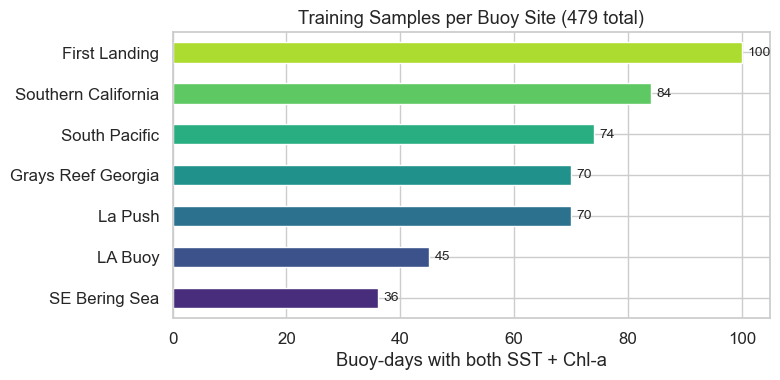

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\training_data_eda\01_samples_per_site.png


In [1]:
# ============================================================
# Plot 1: Per-site sample counts (bar chart)
# Shows how many buoy-days each site contributed to the
# ML-ready dataset (both SST + chl-a present)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Paths
PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOT_DIR = PROJECT_ROOT / "plots" / "training_data_eda"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Load ML-ready data
df = pd.read_csv(PROCESSED_DIR / "training_data_700_ml_ready.csv")
df["date"] = pd.to_datetime(df["date"])
print(f"Loaded {len(df)} ML-ready rows, {df['location'].nunique()} sites")

# Style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Bar chart of samples per site
fig, ax = plt.subplots(figsize=(8, 4))
counts = df["location"].value_counts().sort_values()
colors = sns.color_palette("viridis", n_colors=len(counts))
counts.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Buoy-days with both SST + Chl-a")
ax.set_ylabel("")
ax.set_title("Training Samples per Buoy Site (479 total)")
for i, v in enumerate(counts):
    ax.text(v + 1, i, str(v), va="center", fontsize=10)
plt.tight_layout()
fig.savefig(PLOT_DIR / "01_samples_per_site.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '01_samples_per_site.png'}")


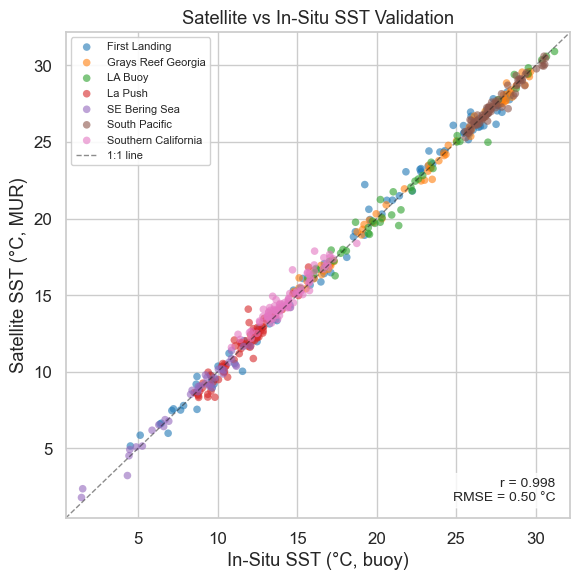

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\training_data_eda\02_sst_validation_scatter.png


In [2]:
# ============================================================
# Plot 2: Satellite SST vs In-Situ SST (validation scatter)
# If the satellite data is good, these should fall along y=x
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

# Color by site
sites = df["location"].unique()
palette = dict(zip(sites, sns.color_palette("tab10", n_colors=len(sites))))

for site in sites:
    sub = df[df["location"] == site]
    ax.scatter(sub["sst_in_situ_mean"], sub["sat_sst_mean"],
               label=site, alpha=0.6, s=30, color=palette[site], edgecolors="none")

# 1:1 line
lims = [df[["sst_in_situ_mean", "sat_sst_mean"]].min().min() - 1,
        df[["sst_in_situ_mean", "sat_sst_mean"]].max().max() + 1]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="1:1 line")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("In-Situ SST (°C, buoy)")
ax.set_ylabel("Satellite SST (°C, MUR)")
ax.set_title("Satellite vs In-Situ SST Validation")
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)

# Add correlation
from scipy import stats as sp_stats
r, p = sp_stats.pearsonr(df["sst_in_situ_mean"], df["sat_sst_mean"])
rmse = ((df["sst_in_situ_mean"] - df["sat_sst_mean"]) ** 2).mean() ** 0.5
ax.text(0.97, 0.03, f"r = {r:.3f}\nRMSE = {rmse:.2f} °C",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
fig.savefig(PLOT_DIR / "02_sst_validation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '02_sst_validation_scatter.png'}")


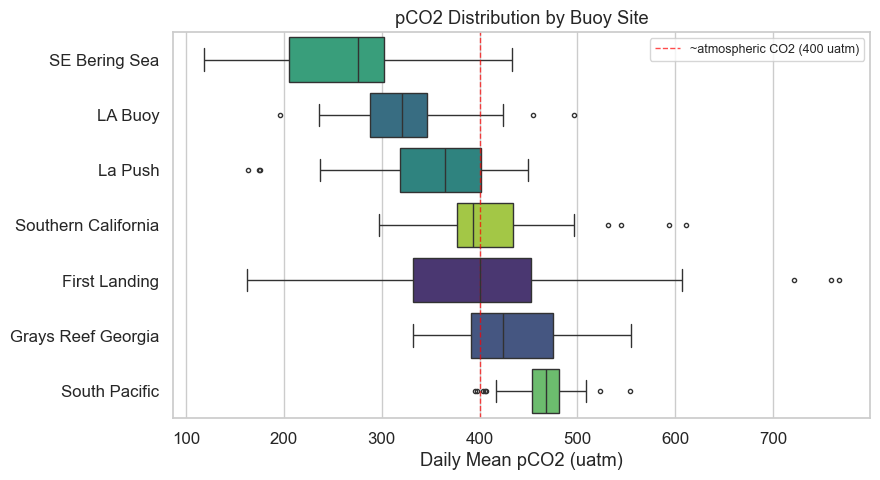

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\training_data_eda\03_pco2_by_site_boxplot.png


In [5]:
# ============================================================
# Plot 3: pCO2 distribution by site (box plot)
# Shows the range and variability of our target variable
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

order = df.groupby("location")["pco2_mean"].median().sort_values().index
sns.boxplot(data=df, x="pco2_mean", y="location", hue="location",
            order=order, palette="viridis", ax=ax, fliersize=3, legend=False)

ax.axvline(x=400, color="red", ls="--", lw=1, alpha=0.7, label="~atmospheric CO2 (400 uatm)")
ax.set_xlabel("Daily Mean pCO2 (uatm)")
ax.set_ylabel("")
ax.set_title("pCO2 Distribution by Buoy Site")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(PLOT_DIR / "03_pco2_by_site_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '03_pco2_by_site_boxplot.png'}")


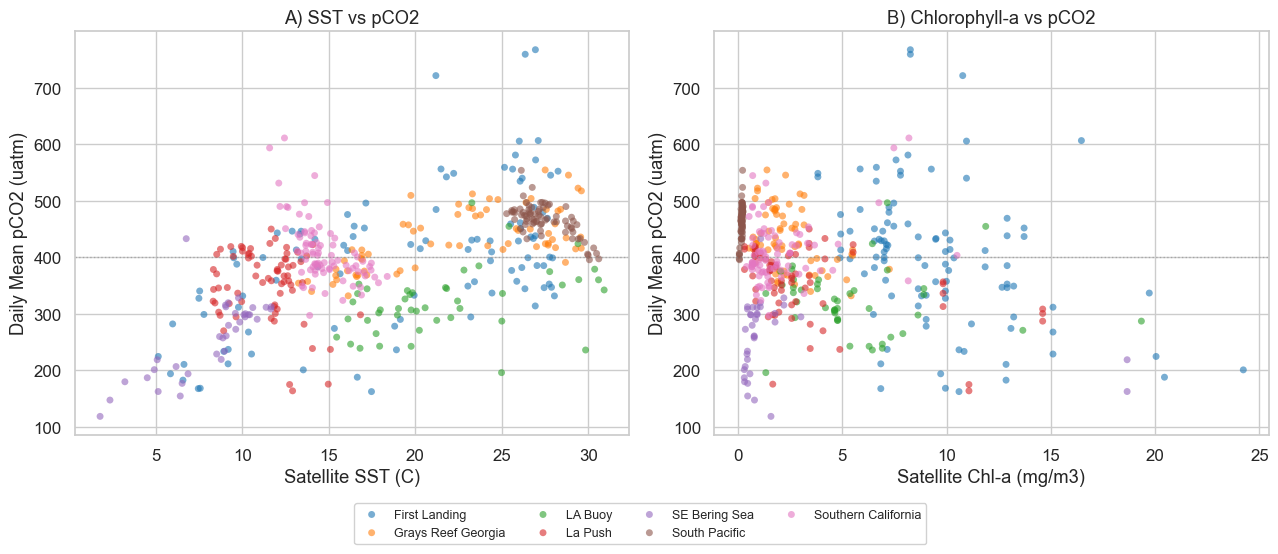

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\training_data_eda\04_sst_chla_vs_pco2.png


In [6]:
# ============================================================
# Plot 4: Multi-panel — SST vs pCO2 and Chl-a vs pCO2
# The two main relationships our ML model will learn
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sites = df["location"].unique()
palette = dict(zip(sites, sns.color_palette("tab10", n_colors=len(sites))))

# --- Panel A: SST vs pCO2 ---
ax = axes[0]
for site in sites:
    sub = df[df["location"] == site]
    ax.scatter(sub["sat_sst_mean"], sub["pco2_mean"],
               label=site, alpha=0.6, s=25, color=palette[site], edgecolors="none")
ax.set_xlabel("Satellite SST (C)")
ax.set_ylabel("Daily Mean pCO2 (uatm)")
ax.set_title("A) SST vs pCO2")
ax.axhline(y=400, color="gray", ls=":", lw=1, alpha=0.5)

# --- Panel B: Chl-a vs pCO2 ---
ax = axes[1]
for site in sites:
    sub = df[df["location"] == site]
    ax.scatter(sub["sat_chla_mean"], sub["pco2_mean"],
               label=site, alpha=0.6, s=25, color=palette[site], edgecolors="none")
ax.set_xlabel("Satellite Chl-a (mg/m3)")
ax.set_ylabel("Daily Mean pCO2 (uatm)")
ax.set_title("B) Chlorophyll-a vs pCO2")
ax.axhline(y=400, color="gray", ls=":", lw=1, alpha=0.5)

# Shared legend at bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(PLOT_DIR / "04_sst_chla_vs_pco2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '04_sst_chla_vs_pco2.png'}")
